In [337]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Разведочный анализ данных для датасета полученного путём парсинга [hirehi.ru](https://hirehi.ru/?category=analytics).

In [338]:
palette = ["#1f2d3a", "#0f766e", "#2a4d69", "#787b7e"]

### Первичный анализ и обработка данных

In [365]:
data = pd.read_csv("hirehi_vacancys.csv")

#### Обработка основной части датасета

In [340]:
# Добавлять сюда - обработка дубликатов, пропусков и тп. Очистка признаков

#### Обработка skills

In [341]:
data["skills"].sample(3)

3220    ['tableau', 'bi-системы', 'анализ метрик', 'cr...
2843    ['c', 'cpp', 'rust', 'javascript', 'typescript...
1361    ['fintech', 'bpmn', 'uml', 'user stories', 'bu...
Name: skills, dtype: object

In [342]:
data["skills"].value_counts()

skills
[]                                                                                                                                                                            55
['typescript', 'react', 'angular', 'git', 'linux', 'mvvm', 'fsd', 'ci/cd', 'тестирование', 'архитектура']                                                                      2
['java', 'devops', 'linux', 'docker', 'kubernetes', 'kafka', 'opensearch', 'postgres']                                                                                         2
['java', 'spring', 'hibernate', 'gradle', 'jms', 'jax-ws', 'junit', 'confluence', 'jira', 'agile', 'devops', 'micro-frontend', 'ios', 'android']                               2
['golang', 'docker', 'postgres', 'rabbitmq', 'kafka', 'grpc', 'rest api', 'grafana', 'prometheus', 'agile', 'nomad', 'consul', 'jaeger', 'opensearch', 'sentry']               2
                                                                                                            

Данные в колонке представлены строковым типом. для дальнейшей обработки преобразуем в массив с помощью функции: 

In [343]:
def str_to_list(skills_string):

    try:
        if not skills_string or skills_string == "[]":
            return []
        skills_string = skills_string[1:-1].split(",")
        skills_list = [
            skill.replace("'", "").strip().lower() for skill in skills_string
        ]
        skills_list = set(skills_list)
        return list(skills_list)

    except Exception:
        return []

Для формирования дополнительного столбца используется метод [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html):

In [344]:
data["skills"] = data["skills"].apply(lambda x: str_to_list(x))
data_skills = (
    data[["id", "skills"]].explode("skills").rename(columns={"skills": "skill"})
)
data_skills

,id,skill
0,36700,manual testing
0,36700,web testing
0,36700,test automation
0,36700,qa
0,36700,test design
...,...,...
8753,24786,bash
8753,24786,nginx
8753,24786,prometheus
8753,24786,postgresql


In [345]:
# data_skills.to_csv("skills.csv", index=False)

### Анализ данных

#### Анализ основных столбцов датасета

In [346]:
# Добавлять сюда

#### Анализ взаимосвязей со skills

Оценим, как распределено количество требуемых инструментов для различных вакансий. Для этого создадим дополнительный признак - `skills_num`.

In [347]:
data["skills_num"] = data["skills"].apply(lambda x: len(x))
skills_length_grouped = data["skills_num"].value_counts()
skills_length_grouped

skills_num
10    1353
15    1199
12    1198
14    1193
13     981
11     959
9      443
8      347
7      246
16     238
6      176
5      112
4       65
17      61
0       55
20      39
18      29
3       27
19      18
2       11
1        4
Name: count, dtype: int64

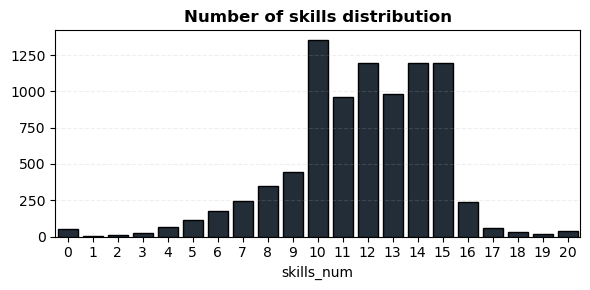

In [348]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    color=palette[0],
    edgecolor="black",
)
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills distribution", fontweight="bold")
plt.tight_layout()

Большинство вакансий требуют от 10 до 15 навыков. При этом наблюдается небольшое число вакансий, для которых навыки не требуются - скорее всего карточка не заполнена

Посмотрим на распределение количества необходимых навыков относительно различных направлений:

In [349]:
data_grouped = data.groupby("category")["skills_num"].mean()
data_grouped

category
analytics      11.633962
design         10.543161
development    11.922481
devops         13.572148
management     11.214158
marketing      10.518265
qa             12.278993
Name: skills_num, dtype: float64

Посмотрим на зависимость количества скиллов от грейда специалиста:

In [350]:
level_groupped = data.groupby("level")["skills_num"].mean()
level_groupped

level
head          11.333333
intern         9.232558
junior         9.871795
lead          11.945312
middle        11.591027
senior        12.317902
грейда нет     6.000000
не указан      9.000000
Name: skills_num, dtype: float64

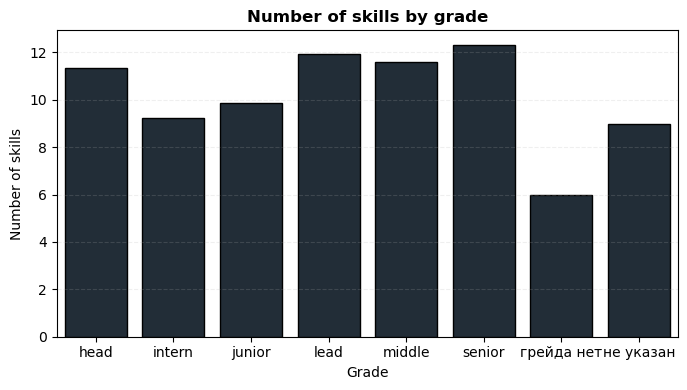

In [351]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=level_groupped, color=palette[0], edgecolor="black")

ax.set_xlabel("Grade")
ax.set_ylabel("Number of skills")
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills by grade", fontweight="bold")
plt.tight_layout()

Посмотрим, какие навыки требуются в самых распространенных вакансиях:

In [352]:
top_4_vac = data["title"].value_counts().iloc[1:5].index
print(f"Топ 3 вакансий: {top_4_vac}")

Топ 3 вакансий: Index(['product manager', 'системный аналитик', 'project manager',
       'devops engineer'],
      dtype='object', name='title')


Для каждой из вакансий выберем наиболее востребованные для неё скиллы:

In [353]:
top_n = 5

skill_title = pd.merge(left=data, right=data_skills, on="id")[["title", "skill"]]
top4_exp = skill_title[skill_title["title"].isin(top_4_vac)]
top4_exp = top4_exp.groupby(["title", "skill"]).size().reset_index(name="skills_num")
top4_exp = top4_exp.sort_values(["title", "skills_num"], ascending=False)

data_skills_topn = []
for vac in top_4_vac:
    data_skills_topn.append(top4_exp[top4_exp["title"] == vac].head(top_n))
data_skills_topn

[                title               skill  skills_num
 848   product manager  product management         107
 907   product manager             roadmap          50
 849   product manager     product manager          45
 1064  product manager           аналитика          44
 454   product manager                  ai          42,
                    title       skill  skills_num
 2245  системный аналитик        bpmn         109
 2498  системный аналитик         sql         105
 2532  системный аналитик         uml          95
 2461  системный аналитик        rest          68
 2267  системный аналитик  confluence          61,
                 title                 skill  skills_num
 1709  project manager    project management         101
 1379  project manager                 agile          65
 1599  project manager                  jira          57
 1761  project manager                 scrum          48
 2169  project manager  управление проектами          39,
                title    

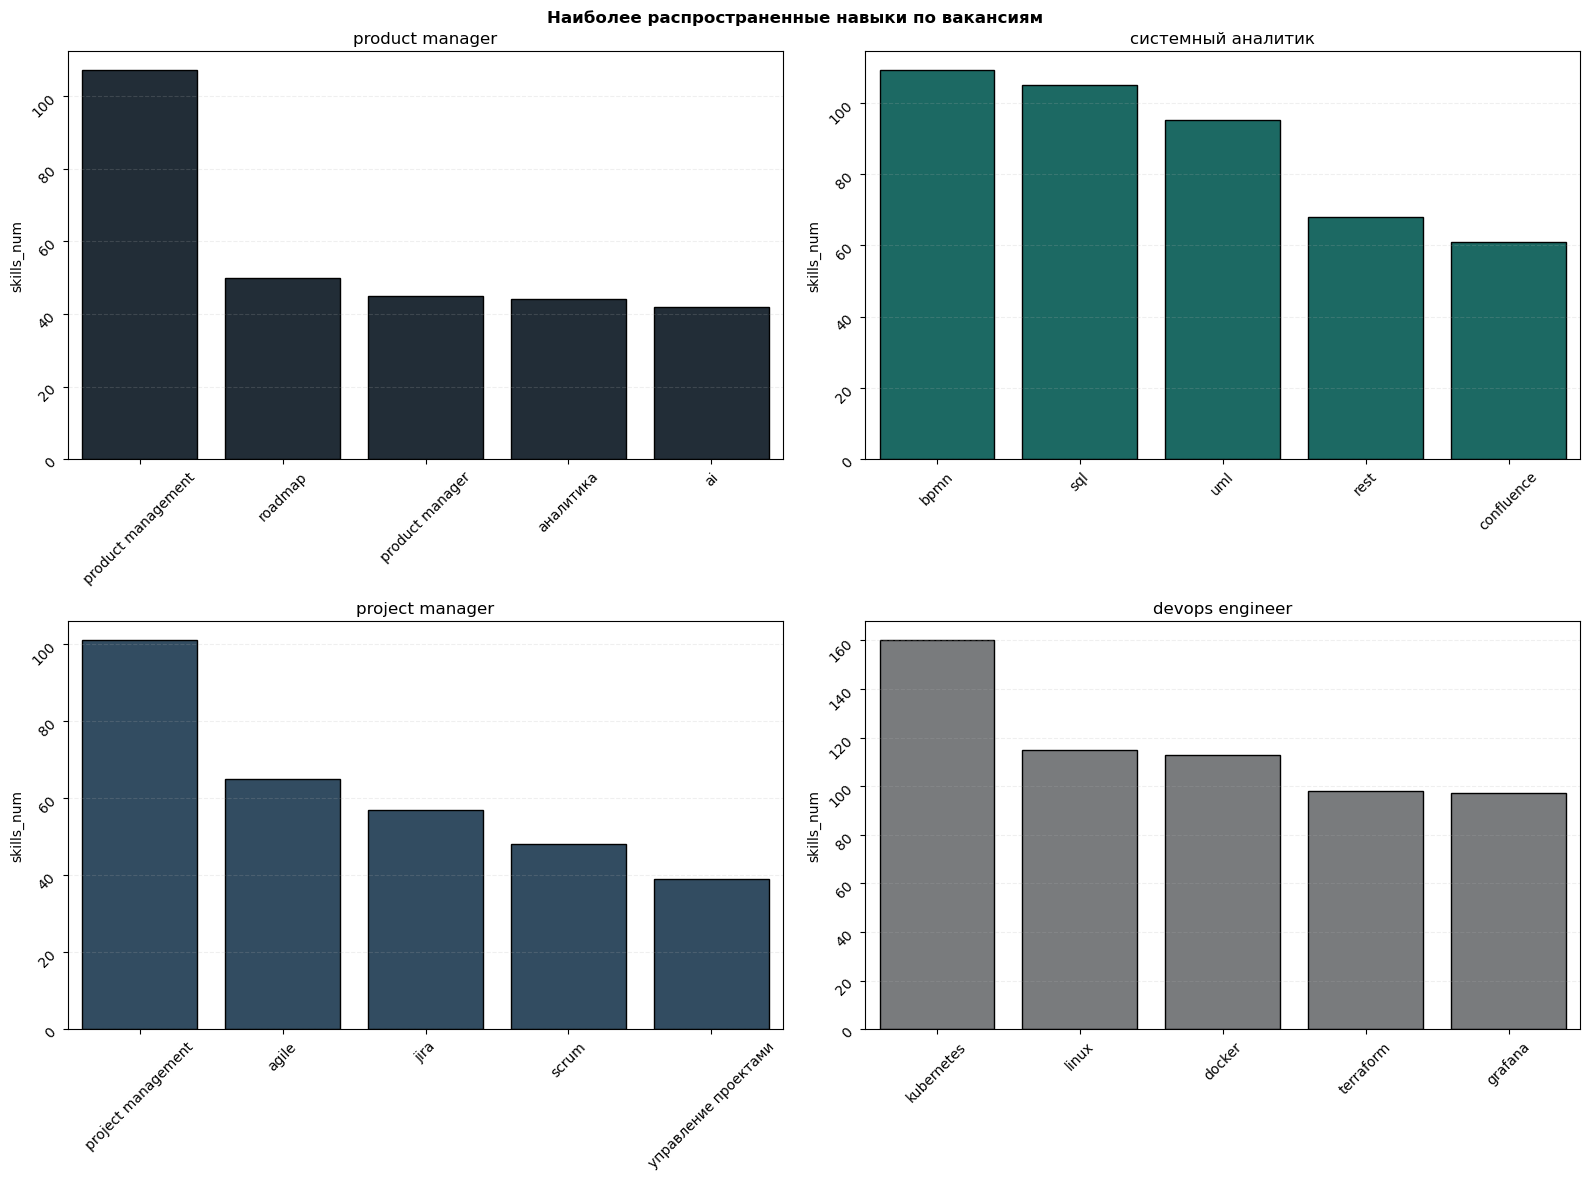

In [354]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Наиболее распространенные навыки по вакансиям", fontweight="bold")
for i in range(4):
    sns.barplot(
        data=data_skills_topn[i],
        x="skill",
        y="skills_num",
        color=palette[i],
        edgecolor="black",
        ax=axes[i // 2][i % 2],
    )
    axes[i // 2][i % 2].grid(axis="y", linestyle="--", alpha=0.2)
    axes[i // 2][i % 2].set_title(top_4_vac[i])
    axes[i // 2][i % 2].tick_params(labelrotation=45)
    axes[i // 2][i % 2].set_xlabel("")
plt.tight_layout()

Использован метод [`tick_params`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html) из библиотеки matplotlib. Необзодимость обусловлена использование объектно ориентированного подхода при оформлении графиков.

Использован метод [`tight_layout`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html) из библиотеки matplotlib. Позволяет улучшить читаемость картинки путем изменения отступов между графиками.

In [355]:
data_skills.isna().sum()

id        0
skill    55
dtype: int64

Количество пропущенных не поменялось, поэтому удалим их из рассмотрения

In [356]:
data_skills = data_skills.dropna()

Дубликаты и кардинальность: 

In [357]:
print(f"Наличе дубликатов:              {data_skills.duplicated().any()}")
print(f"Количество уникальных значений: {data_skills['skill'].nunique()}")

Наличе дубликатов:              False
Количество уникальных значений: 10409


Определим самые часто-встречающиеся навыки:

In [358]:
top_n = 15
skill_stats = data_skills["skill"].value_counts().head(top_n).sort_values()
skill_stats

skill
ai             696
redis          701
аналитика      729
jira           753
typescript     797
linux          850
ci/cd          921
api           1048
kafka         1072
kubernetes    1170
git           1291
docker        1512
postgresql    1519
python        2091
sql           2289
Name: count, dtype: int64

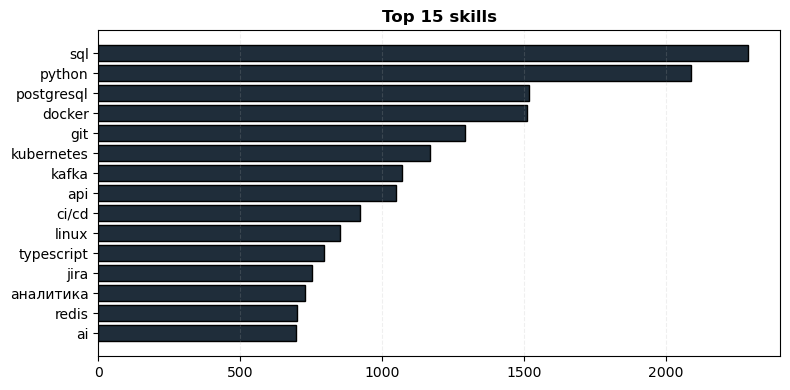

In [359]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    y=skill_stats.index, width=skill_stats.values, edgecolor="black", color=palette[0]
)

ax.grid(axis="x", linestyle="--", alpha=0.2)
ax.set_title(f"Top {top_n} skills", fontweight="bold")
plt.tight_layout()

Попробуем понять, за какой навык платят наибольшую зарплату. Так как в списке навыков есть редко встречающиеся и слабо интерпретируемые навыки, рассмотрим топ 600 самых распространенных навыков. 

In [360]:
top_skills = data_skills["skill"].value_counts().head(600).index
top_skills

Index(['sql', 'python', 'postgresql', 'docker', 'git', 'kubernetes', 'kafka',
       'api', 'ci/cd', 'linux',
       ...
       'llamaindex', 'vertica', 'виртуализация', 'антифрод', 'stripe',
       'отчётность', 'ооп', 'state management', 'распределённые системы',
       'ruby on'],
      dtype='object', name='skill', length=600)

In [361]:
top_exp = data_skills[data_skills["skill"].isin(top_skills)]
top_exp

,id,skill
0,36700,manual testing
0,36700,web testing
0,36700,qa
0,36700,api
0,36700,sdlc
...,...,...
8753,24786,bash
8753,24786,nginx
8753,24786,prometheus
8753,24786,postgresql


In [362]:
skill_salary = pd.merge(left=top_exp, right=data, on="id")[["skill", "salary"]]
skill_salary_grouped = skill_salary.groupby("skill")["salary"].agg(
    ["mean", "median", "count"]
)
skill_salary_grouped = skill_salary_grouped.sort_values(
    ["median", "mean"], ascending=False
)
skill_salary_grouped_top = skill_salary_grouped.head(5)
skill_salary_grouped_top

TypeError: agg function failed [how->mean,dtype->object]

<Axes: xlabel='skill'>

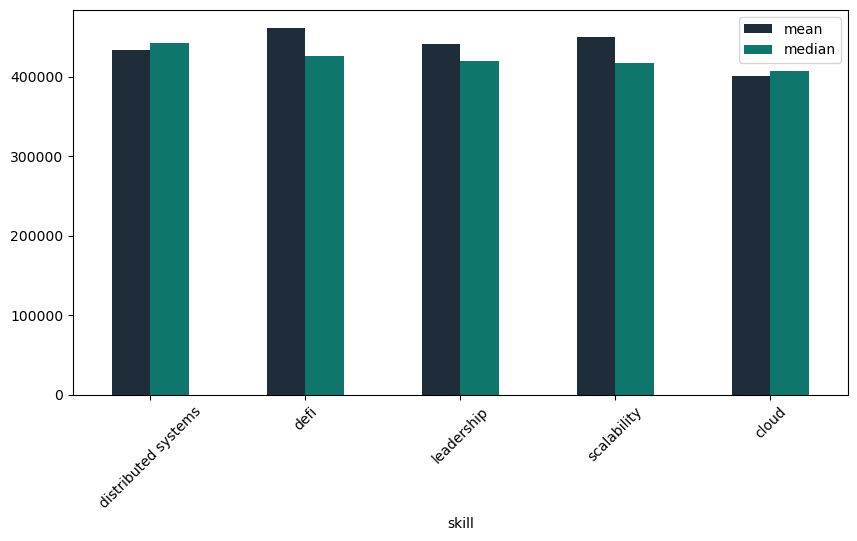

In [ ]:
skill_salary_grouped_top[["mean", "median"]].plot(
    kind="bar", figsize=(10, 5), color=palette, rot=45
)

На основе документации [`plot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).